In [ ]:
print("notebook works")

notebook works


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("numpy", np.__version__)
print("pandas", pd.__version__)
print("seaborn", sns.__version__)


numpy 2.1.3
pandas 2.2.3
seaborn 0.13.2


In [2]:
numbers= [1,2,3,4,5]
print(len(numbers))
print(min(numbers))
print(max(numbers))

print (sum(numbers)/len(numbers))

5
1
5
3.0


In [4]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])
print(arr)
print(type(arr))
print(arr.mean())

[1 2 3 4 5]
<class 'numpy.ndarray'>
3.0


In [5]:
print(arr * 2)
print(arr + 10)
print(arr > 3)

[ 2  4  6  8 10]
[11 12 13 14 15]
[False False False  True  True]


In [6]:
print(arr[arr > 3])

[4 5]


In [9]:
import pandas as pd

df = pd.DataFrame({
    "name": ["Ada", "Ben", "Chi"],
    "score": [80, 95, 70]
})

print(df)

  name  score
0  Ada     80
1  Ben     95
2  Chi     70


In [10]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.describe())

(3, 2)
Index(['name', 'score'], dtype='object')
name     object
score     int64
dtype: object
           score
count   3.000000
mean   81.666667
std    12.583057
min    70.000000
25%    75.000000
50%    80.000000
75%    87.500000
max    95.000000


In [11]:
print(df["score"])
print(df[df["score"] >= 80])

0    80
1    95
2    70
Name: score, dtype: int64
  name  score
0  Ada     80
1  Ben     95


In [12]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
print(df.columns.tolist())
df.head()

(7043, 21)
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
blank = df["TotalCharges"].astype(str).str.strip() == ""
print(blank.sum())
df.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [15]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isna().sum())

float64
11


In [16]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print(df["TotalCharges"].isna().sum())
print(df.loc[[488, 753], ["tenure", "TotalCharges", "Churn"]])

0
     tenure  TotalCharges Churn
488       0           0.0    No
753       0           0.0    No


In [17]:
print(df.duplicated().sum())
print(df["customerID"].duplicated().sum())
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True))

0
0
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


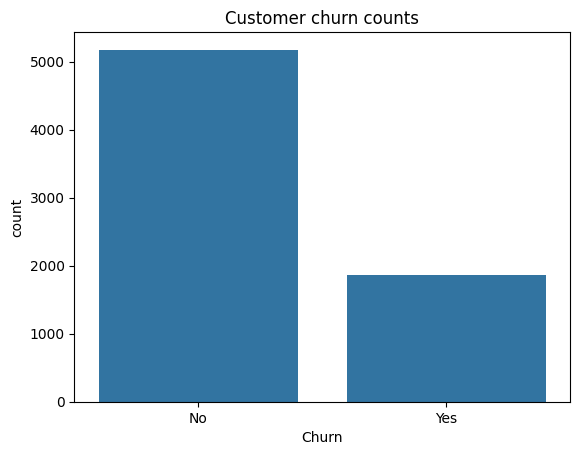

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="Churn")
plt.title("Customer churn counts")
plt.show()

Contract        Churn
Month-to-month  No       0.572903
                Yes      0.427097
One year        No       0.887305
                Yes      0.112695
Two year        No       0.971681
                Yes      0.028319
Name: proportion, dtype: float64


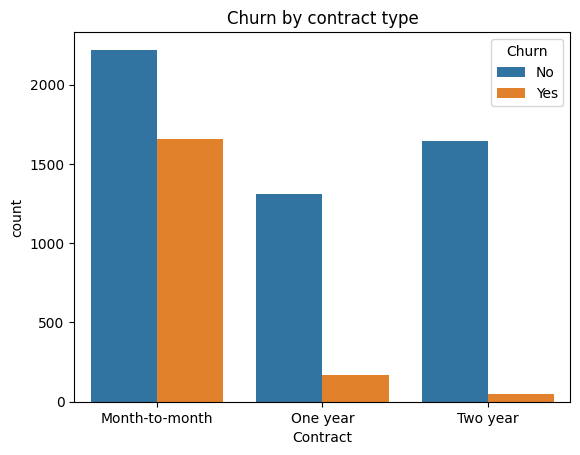

In [20]:
print(df.groupby("Contract")["Churn"].value_counts(normalize=True))

sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by contract type")
plt.show()

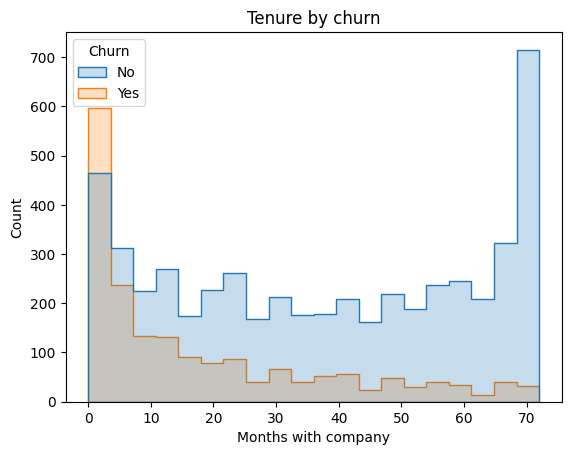

In [21]:
sns.histplot(data=df, x="tenure", hue="Churn", bins=20, element="step")
plt.title("Tenure by churn")
plt.xlabel("Months with company")
plt.show()

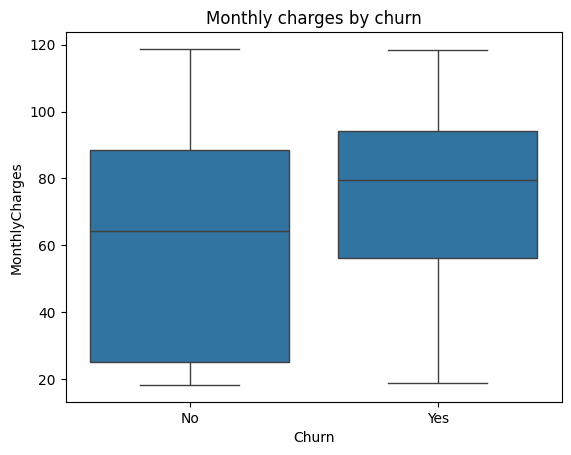

In [22]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly charges by churn")
plt.show()

Findings

About 73.5% of customers stayed and about 26.5%
churned.
Month-to-month customers churned at about 42.7%. One-year was about 11.3%. Two-year was about 2.8%.
Churn is highest near 0 months of tenure and much lower around 70 months.
Customers who churned had higher monthly charges than customers who stayed (median about 80 vs about 65).
11 rows had blank TotalCharges. Those rows had tenure 0 and Churn = No, so I filled TotalCharges with 0.





In [23]:
df.to_csv("telco_churn_cleaned.csv", index=False)
print("saved")

saved
